## Modelo Híbrido

# ¿Cómo funciona?

Este notebook combina los dos modelos anteriores para generar recomendaciones más precisas y variadas.

## Idea general

Cada modelo produce un score independiente para cada canción:

- **Content-Based** → score_contenido basado en similitud de audio
- **Collaborative** → score_colaborativo basado en patrones de usuarios similares

Ambos scores se normalizan al rango [0, 1] y se combinan con un peso α:


score_final = α × score_contenido + (1 - α) × score_colaborativo


## Qué hace este notebook

- Carga el modelo SVD guardado en collaborative.ipynb
- Reconstruye el modelo Content-Based desde items.csv
- Combina ambos scores con ponderación ajustable
- Genera recomendaciones finales con título, artista, género y score
- Permite comparar los tres modelos lado a lado

# Importaciones

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path
from IPython.display import display
from scipy.sparse import hstack, csr_matrix
from sklearn.metrics.pairwise import cosine_similarity

sns.set_theme(style='whitegrid')
np.random.seed(42)

# Paths con fallback igual que en los notebooks anteriores
def resolve_path(primary, fallback):
    p = Path(primary)
    return p if p.exists() else Path(fallback)

ITEMS_PATH        = resolve_path('/data/processed/items.csv',        '../../data/processed/items.csv')
INTERACTIONS_PATH = resolve_path('/data/processed/interactions.csv', '../../data/processed/interactions.csv')
MODEL_PATH        = resolve_path('/data/processed/modelo_svd.pkl',   '../../data/processed/modelo_svd.pkl')

# Features de audio para Content-Based
AUDIO_FEATURES = [
    'danceability', 'energy', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'loudness_norm', 'tempo_norm'
]

# Peso del modelo de contenido (0 = solo colaborativo, 1 = solo contenido)
ALPHA = 0.5

# Carga de Datos y Modelos

In [81]:
# Datos
items = pd.read_csv(ITEMS_PATH)
interactions = pd.read_csv(INTERACTIONS_PATH)

# Consolidar filas duplicadas por ITEM_ID: título/artista = first, género = lista única, popularidad = media
items_indexed = (
    items
    .groupby('ITEM_ID')
    .agg({
        'titulo': 'first',
        'artista': 'first',
        'genero': lambda g: ','.join(sorted(set(g.dropna().astype(str)))),
        'popularidad': 'mean'
    })
    .reset_index()
    .set_index('ITEM_ID')
)

print(f'Canciones: {len(items):,}')
print(f'Interacciones: {len(interactions):,}')

Canciones: 114,000
Interacciones: 750,050


In [82]:
# Modelo colaborativo (guardado por 02_collaborative.ipynb)
with open(MODEL_PATH, 'rb') as f:
    modelo_svd = pickle.load(f)

user_to_idx     = modelo_svd['user_to_idx']
item_to_idx     = modelo_svd['item_to_idx']
idx_to_item     = modelo_svd['idx_to_item']
U               = modelo_svd['U']
S               = modelo_svd['S']
Vt              = modelo_svd['Vt']
media_usuarios  = modelo_svd['media_usuarios']
factores_usuario = modelo_svd['factores_usuario']   # U × Σ

print('Modelo SVD cargado')
print(f'Usuarios en el modelo: {len(user_to_idx):,}')
print(f'Canciones en el modelo: {len(item_to_idx):,}')

Modelo SVD cargado
Usuarios en el modelo: 15,001
Canciones en el modelo: 89,639


# Preparación de modelo content_based

In [83]:
# Matriz de features para Content-Based
# El CSV no trae features de audio, así que usamos género, artista y popularidad.
genre_matrix = csr_matrix(items_indexed['genero'].fillna('').astype(str).str.get_dummies(sep=',').to_numpy(dtype=np.float32))
artist_matrix = pd.get_dummies(items_indexed['artista'].fillna('').astype(str), prefix='artist', sparse=True)
artist_matrix = artist_matrix.sparse.to_coo().tocsr()
popularidad = items_indexed['popularidad'].fillna(0).to_numpy(dtype=float).reshape(-1, 1)

if popularidad.max() > popularidad.min():
    popularidad = (popularidad - popularidad.min()) / (popularidad.max() - popularidad.min())

feature_matrix = hstack([genre_matrix, artist_matrix, csr_matrix(popularidad)], format='csr')
item_ids_list  = items_indexed.index.tolist()
cb_item_to_idx = {item_id: idx for idx, item_id in enumerate(item_ids_list)}

print(f'Matriz de features: {feature_matrix.shape}')
print(f' -> géneros: {genre_matrix.shape[1]}, artistas: {artist_matrix.shape[1]}, popularidad: 1')

Matriz de features: (89741, 31553)
 -> géneros: 114, artistas: 31438, popularidad: 1


# Funciones de Recomendación

In [84]:
def scores_content_based(user_id: str) -> np.ndarray:
    """
    Calcula el score de similitud de coseno entre el perfil
    de audio del usuario y todas las canciones.
    Retorna un array de shape (n_canciones_items,)
    """
    likes = interactions[
        (interactions['USER_ID'] == user_id) &
        (interactions['EVENT_TYPE'] == 'like')
    ]['ITEM_ID'].tolist()

    if not likes:
        # Fallback: usar plays si no tiene likes
        likes = interactions[
            (interactions['USER_ID'] == user_id) &
            (interactions['EVENT_TYPE'] == 'play')
        ]['ITEM_ID'].tolist()

    if not likes:
        return np.zeros(len(item_ids_list))

    indices = [cb_item_to_idx[i] for i in likes if i in cb_item_to_idx]
    perfil  = np.asarray(feature_matrix[indices].mean(axis=0)).ravel().reshape(1, -1)
    return cosine_similarity(perfil, feature_matrix).flatten()


def scores_collaborative(user_id: str) -> np.ndarray:
    """
    Calcula el rating predicho por SVD para todas las canciones del modelo.
    Retorna un array de shape (n_canciones_modelo,)
    """
    if user_id not in user_to_idx:
        return np.zeros(len(item_to_idx))

    u_idx = user_to_idx[user_id]
    # factores_usuario[u] @ Vt reproduce la fila del usuario sin materializar R_pred completa
    return factores_usuario[u_idx] @ Vt + media_usuarios[u_idx]


def normalizar(arr: np.ndarray) -> np.ndarray:
    """Normaliza un array al rango [0, 1]."""
    min_v, max_v = arr.min(), arr.max()
    if max_v == min_v:
        return np.zeros_like(arr)
    return (arr - min_v) / (max_v - min_v)


print('Funciones de scoring definidas')

Funciones de scoring definidas


In [98]:
def recomendar_hibrido(user_id: str, n: int = 10, alpha: float = ALPHA, max_por_artista: int = 1, max_por_genero: int = 2) -> pd.DataFrame:
    """
    Recomienda las N mejores canciones combinando Content-Based y Collaborative.

    Parámetros:
        user_id : ID del usuario
        n       : número de recomendaciones
        alpha   : peso del score de contenido (0=solo collab, 1=solo content)
        max_por_artista : máximo de canciones por artista en el top-N
        max_por_genero : máximo de apariciones por género en el top-N

    Retorna:
        DataFrame con columnas: ITEM_ID, titulo, artista, genero, popularidad,
                                score_contenido, score_colaborativo, score_final
    """
    # Canciones ya escuchadas por el usuario
    ya_vistas = set(interactions[interactions['USER_ID'] == user_id]['ITEM_ID'].tolist())

    # Content-Based 
    sc_raw = scores_content_based(user_id)
    # array sobre items.csv
    sc_norm = normalizar(sc_raw)

    #  Collaborative 
    scol_raw  = scores_collaborative(user_id)
    # array sobre canciones del modelo
    scol_norm = normalizar(scol_raw)

    # Combinar en un DataFrame común 
    # Content-based cubre todos los items; collaborative solo los que vio en entrenamiento
    df_cb = pd.DataFrame({
        'ITEM_ID'           : item_ids_list,
        'score_contenido'   : sc_norm
    })

    df_col = pd.DataFrame({
        'ITEM_ID'             : [idx_to_item[i] for i in range(len(scol_norm))],
        'score_colaborativo'  : scol_norm
    })

    df = df_cb.merge(df_col, on='ITEM_ID', how='left')
    df['score_colaborativo'] = df['score_colaborativo'].fillna(0)

    # Score final 
    df['score_final'] = alpha * df['score_contenido'] + (1 - alpha) * df['score_colaborativo']

    # Excluir ya vistas y ordenar 
    df = df[~df['ITEM_ID'].isin(ya_vistas)]
    df = df.sort_values('score_final', ascending=False)

    # Traer metadata antes del re-ranking para tener acceso a artista/título/género
    meta = items_indexed[['titulo', 'artista', 'genero', 'popularidad']].reset_index()
    df = df.merge(meta, on='ITEM_ID', how='left')

    # Re-ranking simple para evitar que un mismo artista monopolice el top-N
    seleccionados = []
    contador_artistas = {}
    contador_generos = {}
    for _, fila in df.iterrows():
        artista = fila['artista']
        generos_fila = [g.strip() for g in str(fila['genero']).split(',') if g.strip()]
        contador_artistas[artista] = contador_artistas.get(artista, 0)
        puede_agregar = contador_artistas[artista] < max_por_artista
        if puede_agregar and generos_fila:
            for genero in generos_fila:
                if contador_generos.get(genero, 0) >= max_por_genero:
                    puede_agregar = False
                    break
        if puede_agregar:
            seleccionados.append(fila)
            contador_artistas[artista] += 1
            for genero in generos_fila:
                contador_generos[genero] = contador_generos.get(genero, 0) + 1
        if len(seleccionados) == n:
            break

    # Si el filtro deja menos de n resultados, completar sin restricción
    if len(seleccionados) < n:
        faltantes = n - len(seleccionados)
        restantes = df[~df['ITEM_ID'].isin([x['ITEM_ID'] for x in seleccionados])].head(faltantes)
        seleccionados.extend(restantes.to_dict('records'))

    resultado = pd.DataFrame(seleccionados).head(n)

    cols = ['ITEM_ID', 'titulo', 'artista', 'genero', 'popularidad',
            'score_contenido', 'score_colaborativo', 'score_final']
    return resultado[cols].reset_index(drop=True)


print('Función recomendar_hibrido() definida')

Función recomendar_hibrido() definida


# Prueba con Usuario Real

In [86]:
# Usuario con más likes para una prueba representativa
usuario_prueba = interactions[
    interactions['EVENT_TYPE'] == 'like'
]['USER_ID'].value_counts().index[0]

likes = interactions[
    (interactions['USER_ID'] == usuario_prueba) &
    (interactions['EVENT_TYPE'] == 'like')
]['ITEM_ID'].tolist()

print(f'Usuario de prueba: {usuario_prueba} ({len(likes)} likes)')
print('\nSus likes:')
items_indexed.loc[
    [i for i in likes[:5] if i in items_indexed.index],
    ['titulo', 'artista', 'genero']
]

Usuario de prueba: user_4558 (36 likes)

Sus likes:


,titulo,artista,genero
ITEM_ID,,,
3jwcudvYIksoAjU0x6gagd,Valerie,Steve Winwood,"country,folk,singer-songwriter,songwriter"
7tCL3GNUc04W2S7Cx1MzId,Serene Rain,Deep Sleep Rain Sounds,sleep
1wrSlSMgdb4STao5UKN5ML,Rough Day,Rain Sounds,sleep
76CSHuHKMJxmjmdrNBX2Z3,Victoria’s Secret,Jax,"singer-songwriter,songwriter"
1kJvdhrr9MHOZ1e1PhTXTG,Drown,Prateek Kuhad,"folk,indie-pop,singer-songwriter,songwriter"


In [87]:
recomendaciones = recomendar_hibrido(usuario_prueba, n=10, alpha=ALPHA)
print(f'Top 10 recomendaciones híbridas para {usuario_prueba} (α={ALPHA}):')
recomendaciones

Top 10 recomendaciones híbridas para user_4558 (α=0.5):


,ITEM_ID,titulo,artista,genero,popularidad,score_contenido,score_colaborativo,score_final
0,77Y57qRJBvkGCUw9qs0qMg,In the Blood,John Mayer,"singer-songwriter,songwriter",62.000000,0.942279,0.407464,0.674871
1,5wvmIBkBcqg1y5kniumrQk,Cold Shoulders,Prateek Kuhad,"folk,singer-songwriter,songwriter",34.000000,0.937287,0.396469,0.666878
2,32Gf5A7Hr8RdgggXG0Fdks,Have You Ever Really Loved A Woman?,Bryan Adams,"singer-songwriter,songwriter",71.000000,1.000000,0.333340,0.666670
3,7Ewz6bJ97vUqk5HdkvguFQ,Heaven,Bryan Adams,"rock,singer-songwriter,songwriter",77.000000,0.951741,0.379400,0.665570
4,6q7bXTv3yBedHblKRoC5uu,Kadam,Prateek Kuhad,"folk,indian,indie,indie-pop,singer-songwriter,...",51.000000,0.806480,0.520924,0.663702
5,4J0DbyODwZJcmIAiTSJfMF,Annie's Song,John Denver,"country,folk,singer-songwriter,songwriter",71.000000,0.932991,0.392860,0.662925
6,71ejpdyOCAodqqdRjTa0gh,Like My Father - Acoustic Version,Jax,"singer-songwriter,songwriter",53.000000,0.955588,0.367491,0.661540
7,2sY2djYywKHbvT44vI2D57,Jugnoo,Ashwin Adwani,"singer-songwriter,songwriter",33.000000,0.869960,0.451557,0.660759
8,1ZzSy8HeLFZAeuQi577bhB,Ævintýralönd,Hafdís Huld,"folk,singer-songwriter,songwriter",44.333333,0.932937,0.380399,0.656668
9,5TBNZCGMR1NJtJrrg606m0,Nóttin læðist inn,Hafdís Huld,"folk,singer-songwriter,songwriter",44.000000,0.932399,0.379127,0.655763


# Comparación entre modelos

In [88]:
# Recomendaciones de cada modelo por separado
solo_content = recomendar_hibrido(usuario_prueba, n=10, alpha=1.0)
solo_collab  = recomendar_hibrido(usuario_prueba, n=10, alpha=0.0)
hibrido      = recomendar_hibrido(usuario_prueba, n=10, alpha=0.5)

def estilo_tabla(df):
    return (
        df.style
        .hide(axis='index')
        .format({
            'score_contenido': '{:.3f}',
            'score_colaborativo': '{:.3f}',
            'score_final': '{:.3f}',
            'popularidad': '{:.1f}'
        })
        .background_gradient(subset=['score_final'], cmap='Blues')
        .set_properties(**{'text-align': 'left'})
    )

print('── Solo Content-Based (α=1.0) ──')
display(estilo_tabla(solo_content))

print('\n── Solo Collaborative (α=0.0) ──')
display(estilo_tabla(solo_collab))

print('\n── Híbrido (α=0.5) ──')
display(estilo_tabla(hibrido))

── Solo Content-Based (α=1.0) ──


ITEM_ID,titulo,artista,genero,popularidad,score_contenido,score_colaborativo,score_final
32Gf5A7Hr8RdgggXG0Fdks,Have You Ever Really Loved A Woman?,Bryan Adams,"singer-songwriter,songwriter",71.0,1.000,0.333,1.000
2RWFncSWZEhSRRifqiDNVV,Run To You,Bryan Adams,"singer-songwriter,songwriter",70.0,0.999,0.329,0.999
4svaKoxMMP7ImmKrD5hfQu,Victoria’s Secret,Jax,"singer-songwriter,songwriter",82.0,0.984,0.303,0.984
5YVmHTAsdWnoanWXB7AwZX,Like My Father,Jax,"singer-songwriter,songwriter",72.0,0.977,0.310,0.977
1fDsrQ23eTAVFElUMaf38X,American Pie,Don McLean,"folk,singer-songwriter,songwriter",76.0,0.972,0.304,0.972
0VNzEY1G4GLqcNx5qaaTl6,Vincent,Don McLean,"folk,singer-songwriter,songwriter",69.0,0.965,0.331,0.965
3yrSvpt2l1xhsV9Em88Pul,Brown Eyed Girl,Van Morrison,"folk,singer-songwriter,songwriter",80.0,0.954,0.295,0.954
51lPx6ZCSalL2kvSrDUyJc,You're Gonna Live Forever in Me,John Mayer,"singer-songwriter,songwriter",74.0,0.954,0.245,0.954
2jdAk8ATWIL3dwT47XpRfu,Slow Dancing in a Burning Room,John Mayer,"singer-songwriter,songwriter",74.0,0.954,0.346,0.954
2ixsaeFioXJmMgkkbd4uj1,Budapest,George Ezra,"folk,singer-songwriter,songwriter",79.0,0.953,0.294,0.953



── Solo Collaborative (α=0.0) ──


ITEM_ID,titulo,artista,genero,popularidad,score_contenido,score_colaborativo,score_final
0T7DQlfcadEUEjxoHeQQaL,Labios Rotos - En Vivo,Zoé,"alt-rock,alternative,indie,latin,rock",0.0,0.092,0.566,0.566
6q7bXTv3yBedHblKRoC5uu,Kadam,Prateek Kuhad,"folk,indian,indie,indie-pop,singer-songwriter,songwriter",51.0,0.806,0.521,0.521
5U0t4SMp344ER0F4jYb6xI,The Boys Of Summer,Don Henley,"country,folk,singer-songwriter,songwriter",0.0,0.790,0.515,0.515
7eTy1IzCaICfm6JYy1BV4u,with you/for you,Prateek Kuhad,"folk,indian,indie,indie-pop,singer-songwriter,songwriter",46.0,0.799,0.513,0.513
5RhWszHMSKzb7KiXk4Ae0M,One Last Kiss,Hikaru Utada,"anime,j-pop,singer-songwriter,songwriter",64.5,0.731,0.500,0.500
73fRMyckZKtemX14eku8uu,Dandini Dandini Dastana,Sertab Erener,"j-pop,jazz,singer-songwriter,songwriter,turkish",48.0,0.647,0.494,0.494
6lVtX3nLHyWZP7aqU9HuVW,Heads Will Roll,Yeah Yeah Yeahs,"alt-rock,alternative,indie,punk,punk-rock",0.0,0.037,0.493,0.493
6CqIPNIgAYmbOyPgVKv0u3,Christmas Time's A-Coming,Emmylou Harris,"country,folk,singer-songwriter,songwriter",0.0,0.790,0.480,0.480
1ml3WGeluftee3DiSfyIGx,Right Down the Line,Gerry Rafferty,"country,folk,singer-songwriter,songwriter",0.0,0.790,0.465,0.465
4aqS25F3ywJ9TGnNkOqilC,Abracadabra - Remastered 2017,Steve Miller Band,"blues,country,folk,hard-rock,psych-rock,singer-songwriter,songwriter",2.3,0.629,0.462,0.462



── Híbrido (α=0.5) ──


ITEM_ID,titulo,artista,genero,popularidad,score_contenido,score_colaborativo,score_final
77Y57qRJBvkGCUw9qs0qMg,In the Blood,John Mayer,"singer-songwriter,songwriter",62.0,0.942,0.407,0.675
5wvmIBkBcqg1y5kniumrQk,Cold Shoulders,Prateek Kuhad,"folk,singer-songwriter,songwriter",34.0,0.937,0.396,0.667
32Gf5A7Hr8RdgggXG0Fdks,Have You Ever Really Loved A Woman?,Bryan Adams,"singer-songwriter,songwriter",71.0,1.000,0.333,0.667
7Ewz6bJ97vUqk5HdkvguFQ,Heaven,Bryan Adams,"rock,singer-songwriter,songwriter",77.0,0.952,0.379,0.666
6q7bXTv3yBedHblKRoC5uu,Kadam,Prateek Kuhad,"folk,indian,indie,indie-pop,singer-songwriter,songwriter",51.0,0.806,0.521,0.664
4J0DbyODwZJcmIAiTSJfMF,Annie's Song,John Denver,"country,folk,singer-songwriter,songwriter",71.0,0.933,0.393,0.663
71ejpdyOCAodqqdRjTa0gh,Like My Father - Acoustic Version,Jax,"singer-songwriter,songwriter",53.0,0.956,0.367,0.662
2sY2djYywKHbvT44vI2D57,Jugnoo,Ashwin Adwani,"singer-songwriter,songwriter",33.0,0.870,0.452,0.661
1ZzSy8HeLFZAeuQi577bhB,Ævintýralönd,Hafdís Huld,"folk,singer-songwriter,songwriter",44.3,0.933,0.380,0.657
5TBNZCGMR1NJtJrrg606m0,Nóttin læðist inn,Hafdís Huld,"folk,singer-songwriter,songwriter",44.0,0.932,0.379,0.656


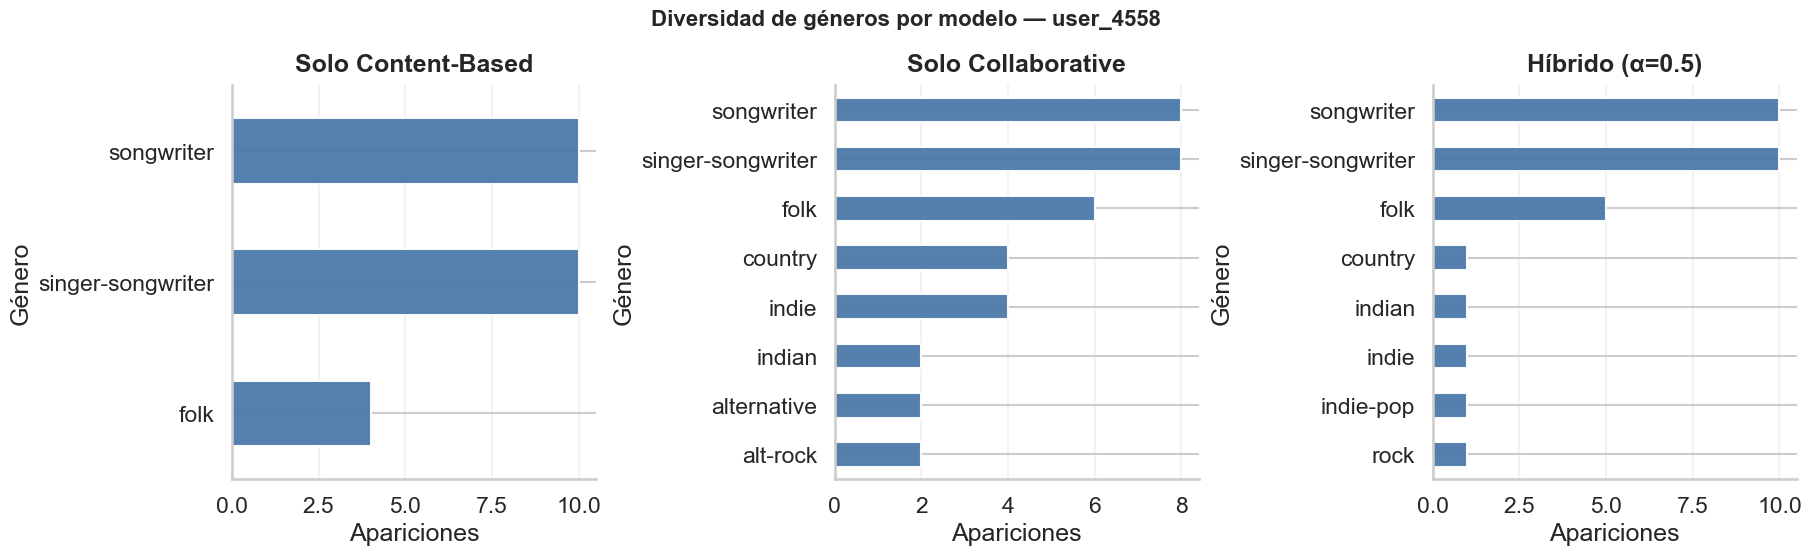

In [89]:
# Diversidad de géneros por modelo
sns.set_theme(style='whitegrid', context='talk')
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
fig.patch.set_facecolor('white')

for ax, (titulo, df) in zip(axes, [
    ('Solo Content-Based', solo_content),
    ('Solo Collaborative', solo_collab),
    ('Híbrido (α=0.5)',    hibrido)
]):
    generos = (
        df['genero']
        .fillna('')
        .astype(str)
        .str.split(',')
        .explode()
        .str.strip()
    )
    generos = generos[generos != '']
    top_generos = generos.value_counts().head(8)
    top_generos.sort_values().plot(kind='barh', ax=ax, color='#4C78A8', edgecolor='white', alpha=0.95)
    ax.set_title(titulo, pad=10, fontweight='bold')
    ax.set_xlabel('Apariciones')
    ax.set_ylabel('Género')
    ax.grid(axis='x', alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle(f'Diversidad de géneros por modelo — {usuario_prueba}', y=1.08, fontsize=16, fontweight='bold')
plt.show()

# Efecto de α en las Recomendaciones

In [90]:
# Ver cómo cambia el score_final según alpha
alphas = [0.0, 0.25, 0.5, 0.75, 1.0]

print(f'Top 5 canciones para {usuario_prueba} según α:\n')
print(f'{"Canción":<35} {" | ".join([f"α={a}" for a in alphas])}')
print('-' * 80)

for a in alphas:
    top5 = recomendar_hibrido(usuario_prueba, n=5, alpha=a)
    print(f'\nα = {a}')
    print(top5[['titulo', 'genero', 'score_final']].to_string(index=False))

Top 5 canciones para user_4558 según α:

Canción                             α=0.0 | α=0.25 | α=0.5 | α=0.75 | α=1.0
--------------------------------------------------------------------------------

α = 0.0
                titulo                                                   genero  score_final
Labios Rotos - En Vivo                    alt-rock,alternative,indie,latin,rock     0.566039
                 Kadam folk,indian,indie,indie-pop,singer-songwriter,songwriter     0.520924
    The Boys Of Summer                country,folk,singer-songwriter,songwriter     0.514901
      with you/for you folk,indian,indie,indie-pop,singer-songwriter,songwriter     0.513239
         One Last Kiss                 anime,j-pop,singer-songwriter,songwriter     0.499815

α = 0.25
                   titulo                                                   genero  score_final
                    Kadam folk,indian,indie,indie-pop,singer-songwriter,songwriter     0.592313
         with you/for you folk,in

# Prueba con cualquier usuario

In [100]:
USER_ID_PRUEBA    = 'user_5001'
N_RECOMENDACIONES = 5
ALPHA_PRUEBA      = 0.5

resultado = recomendar_hibrido(USER_ID_PRUEBA, n=N_RECOMENDACIONES, alpha=ALPHA_PRUEBA)
print(f'Recomendaciones híbridas para {USER_ID_PRUEBA} (α={ALPHA_PRUEBA}):')
resultado

Recomendaciones híbridas para user_5001 (α=0.5):


,ITEM_ID,titulo,artista,genero,popularidad,score_contenido,score_colaborativo,score_final
0,0r0F6NEGEI6JFGfhtWLSYC,Weed Smokers,Vybz Kartel,"dancehall,j-dance",27.0,0.986177,0.600162,0.793169
1,48eDHR9rcXM4qpJwfXyUhG,Unbreakable,Rygin King,"dancehall,j-dance",28.0,0.939063,0.621677,0.780370
2,5h1L6nOR9QYXeeNW14aeus,Pause,Prateek Kuhad,"folk,indian,indie,indie-pop,singer-songwriter,...",51.0,0.106736,0.902724,0.504730
3,2Ey6v4Sekh3Z0RUSISRosD,Layla,Derek & The Dominos,"blues,british,country,folk,hard-rock,psych-roc...",0.0,0.000000,1.000000,0.500000
4,2aibwv5hGXSgw7Yru8IYTO,Snow (Hey Oh),Red Hot Chili Peppers,"alt-rock,alternative,funk,metal,rock",80.0,0.098118,0.815464,0.456791
